<a href="https://colab.research.google.com/github/trqshgodyz/AirQuality/blob/main/guides/linked/ee-api-colab-setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Extracting monthly data from Google Earth Engine... (This takes about 1-2 minutes)
Extraction complete! Generating charts...


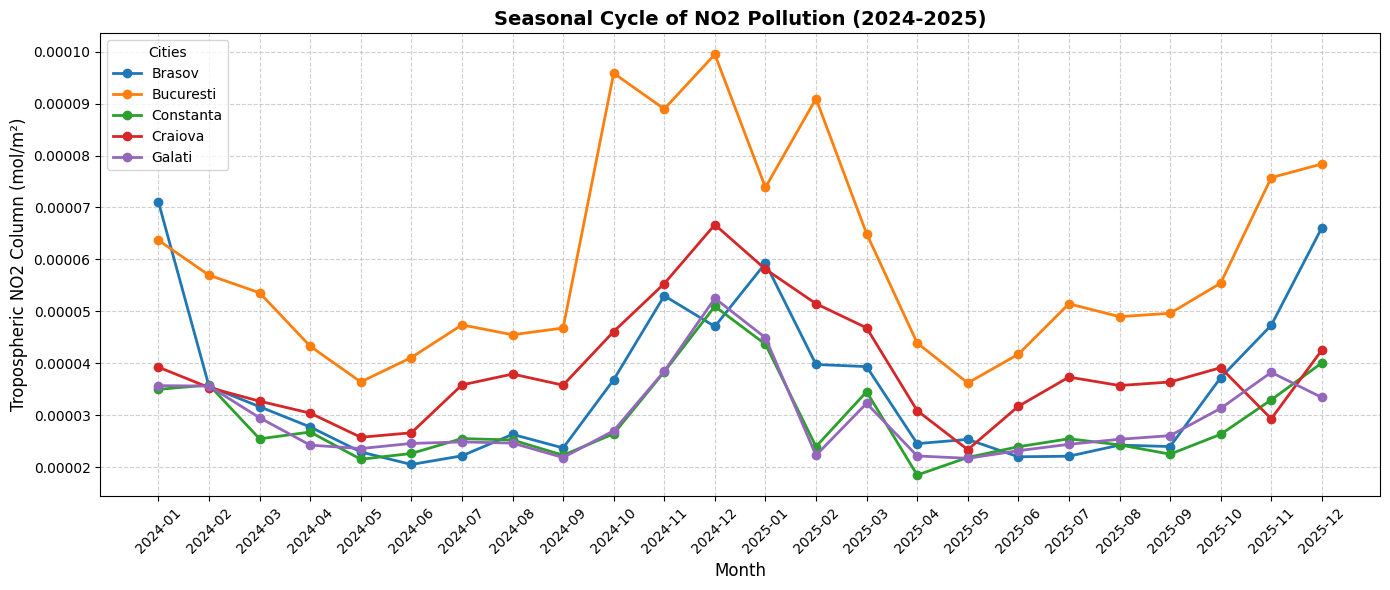

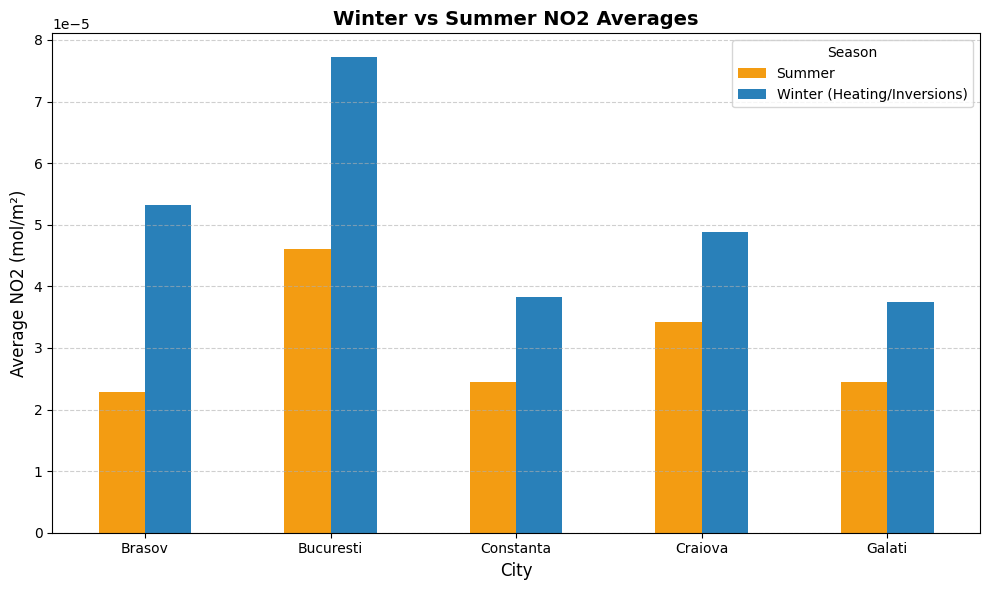


--- Annual NO2 Averages (mol/m²) ---
year           2024      2025
city                         
Brasov     0.000035  0.000036
Bucuresti  0.000060  0.000059
Constanta  0.000030  0.000028
Craiova    0.000039  0.000039
Galati     0.000030  0.000029
------------------------------------

--- Year-over-Year Change ---
year      % Change
city              
Brasov       3.03%
Bucuresti   -1.08%
Constanta   -5.03%
Craiova     -1.05%
Galati      -4.74%
-----------------------------


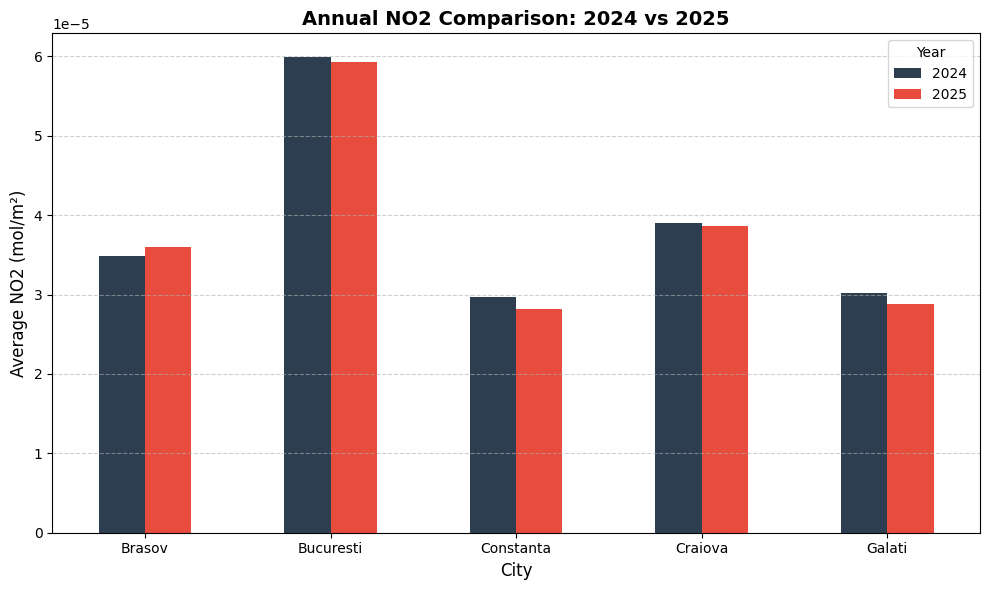


   SEASONAL NO2 AVERAGES: WINTER VS SUMMER

Absolute Values (mol/m²):
season       Summer  Winter (Heating/Inversions)
city                                            
Brasov     0.000023                     0.000053
Bucuresti  0.000046                     0.000077
Constanta  0.000025                     0.000038
Craiova    0.000034                     0.000049
Galati     0.000025                     0.000037
--------------------------------------------------

Winter vs Summer Ratio (e.g., 2.0 means winter is twice as polluted):
season     Winter/Summer Ratio
city                          
Brasov                    2.32
Bucuresti                 1.68
Constanta                 1.56
Craiova                   1.43
Galati                    1.53


   GENERAL OVERALL NO2 AVERAGES (2024 - 2025)

Overall Baseline Pollution (Ranked Highest to Lowest):
           Overall_Mean_NO2
city                       
Bucuresti          0.000060
Craiova            0.000039
Brasov             0.000035
Gal

In [7]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project='airquality-508516')
# 1. Redefine Romania as a Feature (Not just a raw geometry) so we can style it
countries = ee.FeatureCollection('FAO/GAUL_SIMPLIFIED_500m/2015/level0')
romania_feature = countries.filter(ee.Filter.eq('ADM0_NAME', 'Romania'))
romania_geom = romania_feature.geometry()

# 2. Fix the disappearing circles by adding maxError=1
city_radius = 10000
cities = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([26.1025, 44.4268]).buffer(city_radius, 1), {'city': 'Bucuresti'}),
    ee.Feature(ee.Geometry.Point([28.0503, 45.4353]).buffer(city_radius, 1), {'city': 'Galati'}),
    ee.Feature(ee.Geometry.Point([23.7949, 44.3302]).buffer(city_radius, 1), {'city': 'Craiova'}),
    ee.Feature(ee.Geometry.Point([28.6348, 44.1598]).buffer(city_radius, 1), {'city': 'Constanta'}),
    ee.Feature(ee.Geometry.Point([25.6012, 45.6579]).buffer(city_radius, 1), {'city': 'Brasov'})
])

# 3. Relax the cloud filter slightly to prevent empty datasets in winter
def filter_s5p_advanced(image):
    cloud_frac = image.select('cloud_fraction')
    no2 = image.select('tropospheric_NO2_column_number_density')

    # Relaxed cloud_fraction to 0.4 (40%) to ensure better coverage
    valid_mask = cloud_frac.lte(0.4).And(no2.gte(0))

    return (image.updateMask(valid_mask)
            .select('tropospheric_NO2_column_number_density')
            .rename('NO2')
            .copyProperties(image, ['system:time_start']))

# 4. Generate the Collections
no2_collection = (
    ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2')
    .filterDate('2024-01-01', '2026-01-01')
    .filterBounds(romania_geom)
    .map(filter_s5p_advanced)
)

no2_2024_median = no2_collection.filterDate('2024-01-01', '2025-01-01').median().clip(romania_geom)
no2_2025_median = no2_collection.filterDate('2025-01-01', '2026-01-01').median().clip(romania_geom)

difference = no2_2025_median.subtract(no2_2024_median)

# 5. Display the Map (With Country Contour)
Map = geemap.Map(basemap='ROADMAP')
Map.centerObject(romania_geom, 6)

# Visualization params
no2_vis = {
    'min': 0,
    'max': 0.00012,
    'palette': ['081d58', '253494', '225ea8', '1d91c0', '41b6c4', '7fcdbb', 'c7e9b4', 'ffffcc', 'fed976', 'fd8d3c', 'e31a1c']
}

diff_vis = {
    'min': -0.00003,
    'max': 0.00003,
    'palette': ['08306b', '2171b5', '6baed6', 'f7fbff', 'fee0d2', 'fc9272', 'cb181d']
}

# Add layers (Remember: these take ~30-45 seconds to load!)
Map.addLayer(no2_2024_median, no2_vis, 'Median NO2 2024')
Map.addLayer(no2_2025_median, no2_vis, 'Median NO2 2025', False)
Map.addLayer(difference, diff_vis, 'Diff (2025 - 2024)', False)

# Add Romania Outline (Thick black border, completely transparent inside)
Map.addLayer(
    romania_feature.style(color='000000', fillColor='00000000', width=3),
    {},
    'Romania Contour'
)

# Add perfectly round City Buffers (Red border)
Map.addLayer(
    cities.style(color='ff0000', fillColor='00000000', width=2),
    {},
    'Target Cities (10km)'
)

Map.add_colorbar(no2_vis, label='Tropospheric NO2 (mol/m²)')
Map

print("Extracting monthly data from Google Earth Engine... (This takes about 1-2 minutes)")

records = []
years = [2024, 2025]
scale = 1113.2  # Sentinel-5P resolution in meters

# Loop through each year and month
for year in years:
    for month in range(1, 13):
        start_date = ee.Date.fromYMD(year, month, 1)
        end_date = start_date.advance(1, 'month')

        # Calculate the median NO2 for this specific month
        monthly_img = no2_collection.filterDate(start_date, end_date).median()

        # Extract the average NO2 value within each city's 10km buffer
        stats = monthly_img.reduceRegions(
            collection=cities,
            reducer=ee.Reducer.mean(),
            scale=scale
        ).getInfo()  # .getInfo() pulls the data from Google's servers to your Python environment

        # Parse the data into a list of dictionaries
        for feature in stats['features']:
            records.append({
                'city': feature['properties']['city'],
                'date': f"{year}-{month:02d}",
                'year': year,
                'month': month,
                'NO2_mean': feature['properties'].get('mean', None) # Safely get the mean, or None if cloudy
            })

# Convert to Pandas DataFrame
df = pd.DataFrame(records)

# Drop any months where a city had absolutely zero valid pixels (NaN)
df = df.dropna(subset=['NO2_mean'])

print("Extraction complete! Generating charts...")

# --- CHART 1: The Seasonal Cycle (Monthly Time Series) ---
fig, ax = plt.subplots(figsize=(14, 6))

# Plot a line for each city
for city_name, group in df.groupby('city'):
    sorted_group = group.sort_values('date')
    ax.plot(sorted_group['date'], sorted_group['NO2_mean'], marker='o', linewidth=2, label=city_name)

ax.set_title('Seasonal Cycle of NO2 Pollution (2024-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Tropospheric NO2 Column (mol/m²)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Cities')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- CHART 2: Winter vs Summer Comparison ---
# Define Winter (Dec, Jan, Feb) and Summer (Jun, Jul, Aug)
df['season'] = df['month'].apply(
    lambda m: 'Winter (Heating/Inversions)' if m in [12, 1, 2] else ('Summer' if m in [6, 7, 8] else 'Other')
)

df_season = df[df['season'].isin(['Winter (Heating/Inversions)', 'Summer'])].groupby(['city', 'season'])['NO2_mean'].mean().unstack()

fig2, ax2 = plt.subplots(figsize=(10, 6))
df_season.plot(kind='bar', ax=ax2, color=['#f39c12', '#2980b9'])

ax2.set_title('Winter vs Summer NO2 Averages', fontsize=14, fontweight='bold')
ax2.set_xlabel('City', fontsize=12)
ax2.set_ylabel('Average NO2 (mol/m²)', fontsize=12)
ax2.tick_params(axis='x', rotation=0)
ax2.legend(title='Season')
ax2.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- TABLE & CHART 3: Annual Comparison 2024 vs 2025 ---
# Group the data by city and year, calculate the mean, and format as a table
df_annual = df.groupby(['city', 'year'])['NO2_mean'].mean().unstack()

# 1. Print the numerical table to the console
print("\n--- Annual NO2 Averages (mol/m²) ---")
print(df_annual.round(6))  # Rounded for easier reading
print("-" * 36)

# Calculate the percentage change to see if pollution got better or worse
df_annual['% Change'] = ((df_annual[2025] - df_annual[2024]) / df_annual[2024]) * 100
print("\n--- Year-over-Year Change ---")
print(df_annual[['% Change']].round(2).astype(str) + '%')
print("-" * 29)

# 2. Plot the Annual Comparison Bar Chart
fig3, ax3 = plt.subplots(figsize=(10, 6))

# Plot only the 2024 and 2025 columns (dropping the % Change column for the plot)
df_annual[[2024, 2025]].plot(kind='bar', ax=ax3, color=['#2c3e50', '#e74c3c'])

ax3.set_title('Annual NO2 Comparison: 2024 vs 2025', fontsize=14, fontweight='bold')
ax3.set_xlabel('City', fontsize=12)
ax3.set_ylabel('Average NO2 (mol/m²)', fontsize=12)
ax3.tick_params(axis='x', rotation=0)
ax3.legend(title='Year')
ax3.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- NUMERIC DATA: Summer vs Winter ---
print("\n" + "="*50)
print("   SEASONAL NO2 AVERAGES: WINTER VS SUMMER")
print("="*50)

# We use the df_season we calculated earlier for the bar chart
print("\nAbsolute Values (mol/m²):")
print(df_season.round(6))
print("-" * 50)

# Calculate how many times worse winter is compared to summer
df_season['Winter/Summer Ratio'] = df_season['Winter (Heating/Inversions)'] / df_season['Summer']
print("\nWinter vs Summer Ratio (e.g., 2.0 means winter is twice as polluted):")
print(df_season[['Winter/Summer Ratio']].round(2))

# --- NUMERIC DATA: General / Overall Statistics ---
print("\n\n" + "="*50)
print("   GENERAL OVERALL NO2 AVERAGES (2024 - 2025)")
print("="*50)

# Calculate the all-time average for each city across the entire 2-year period
df_overall = df.groupby('city')['NO2_mean'].mean().to_frame(name='Overall_Mean_NO2')
# Sort from most polluted to least polluted
df_overall = df_overall.sort_values(by='Overall_Mean_NO2', ascending=False)

print("\nOverall Baseline Pollution (Ranked Highest to Lowest):")
print(df_overall.round(6))

# --- NUMERIC DATA: Monthly Breakdown ---
print("\n\n" + "="*50)
print("   AVERAGE MONTHLY NO2 (Combined 2024 & 2025)")
print("="*50)

# Create a table showing the average for each month (1 = Jan, 12 = Dec) across all cities
df_monthly_avg = df.groupby(['city', 'month'])['NO2_mean'].mean().unstack()

print("\nMonthly Averages (mol/m²):")
print(df_monthly_avg.round(6))